In [2]:
import gc
import os
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # suppress CUDA errors
import tensorflow as tf
from keras import mixed_precision, utils, saving, layers, losses, optimizers, metrics, callbacks, Sequential
from sklearn import model_selection

mixed_precision.set_global_policy('mixed_float16') # https://keras.io/2/api/mixed_precision/policy/
utils.set_random_seed(42)

In [3]:
data = pl.read_csv('train.csv').drop('date_id').with_columns(
    pl.all().cast(pl.Float64, strict=False),
    pl.col('forward_returns').shift(-1).alias('lagged_forward_returns'),
    pl.col('risk_free_rate').shift(-1).alias('lagged_risk_free_rate'),
    pl.col('market_forward_excess_returns').shift(-1).alias('lagged_market_forward_excess_returns'),
).drop_nulls()
data

D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,I8,…,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns,lagged_forward_returns,lagged_risk_free_rate,lagged_market_forward_excess_returns
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.682135,0.017196,0.007937,0.007937,0.007937,0.007937,0.04828,1.148054,1.303514,1.046752,-0.934762,1.672142,1.6885,0.467403,0.00496,0.979828,0.035384,1.036085,-1.509582,0.019511,0.920966,-1.701971,0.604167,0.112434,3.264191,0.868386,0.588624,0.015542,…,0.901124,-0.352882,-0.32555,-0.384918,1.952492,0.009259,0.54665,0.837302,0.447751,-0.035114,-0.817238,-0.852928,0.141534,-0.117783,0.025463,0.41832,0.175176,0.974868,0.98082,-0.950543,0.998016,0.950066,-0.632577,1.0,0.976852,0.996693,0.534651,0.884921,-0.911387,0.979167,-0.847754,0.001145,0.00004,0.000797,0.004738,0.00004,0.00439
0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.681101,0.016865,0.007606,0.007606,0.007606,0.007606,0.008267,1.146588,1.303443,1.047816,-0.840081,1.679036,1.681503,0.476048,0.00463,0.980159,0.035053,1.034762,-1.508327,0.01918,0.911706,-1.699698,0.552249,0.112103,3.26995,0.878968,0.548942,0.00463,…,0.394511,-0.527326,-0.024274,-0.366401,1.951974,0.013889,0.532708,0.587302,0.455026,0.786992,-1.080408,-0.674757,0.271164,-0.154889,0.035384,0.418651,0.172465,0.853175,0.994709,-0.926755,0.98545,0.88922,-0.570402,1.0,0.986772,0.997354,0.283256,0.76918,-0.842354,0.970238,-0.821913,0.004738,0.00004,0.00439,0.006016,0.00004,0.005669
0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.680068,0.016534,0.007275,0.007275,0.007275,0.007275,0.007937,1.145124,1.303371,1.048881,-0.919572,1.732292,1.674528,0.539929,0.004299,0.980489,0.034722,1.033442,-1.507079,0.018849,0.893519,-1.725246,0.576389,0.231151,3.210036,0.873016,0.618386,0.013228,…,0.100198,-0.643844,0.04599,0.323175,1.95768,0.029762,0.478909,0.579365,0.397487,0.887609,-0.885854,-0.467836,0.205026,-0.084868,0.035053,0.587963,0.183262,0.938492,0.986772,-0.909063,0.976852,0.75,-0.633219,1.0,0.962963,0.999339,0.713303,0.814153,-0.933089,0.95172,-0.817906,0.006016,0.00004,0.005669,0.001414,0.000039,0.001067
0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.679035,0.016204,0.006944,0.006944,0.006944,0.006944,0.007606,1.120467,2.311946,1.049948,-0.897883,1.799013,1.678219,0.620491,0.003968,0.98082,0.034392,1.035746,-1.465905,0.018519,0.925926,-1.694847,0.556548,0.23082,3.120156,0.804894,0.531085,0.006614,…,0.387566,-0.598069,-0.144492,0.975198,1.962668,0.030423,0.487219,0.143519,0.088624,2.393173,-1.018689,-0.270453,0.113095,-0.268138,0.058862,0.588294,0.125405,0.884921,0.970899,-0.939337,0.983466,0.743386,-0.714956,1.0,0.946429,1.0,0.583019,0.809524,-1.051731,0.953042,-0.887412,0.001414,0.000039,0.001067,-0.007182,0.000039,-0.007529
0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.678003,0.015873,0.006614,0.006614,0.006614,0.006614,0.007275,1.119052,2.308384,1.051017,-1.060261,1.819273,1.722944,0.646119,0.003638,0.981151,0.034061,0.886804,-1.464726,0.018188,0.878968,-1.77633,0.565476,0.111772,3.134921,0.80291,0.585648,0.009259,…,0.850198,-0.076645,-0.325459,0.770006,1.962839,0.033069,0.485576,0.910714,0.719577,0.176177,-0.626875,-0.170259,0.482143,-0.498902,0.089947,0.588624,0.21133,0.586971,0.972884,-0.967596,0.972884,0.700397,-0.766562,0.998016,0.960979,0.999339,1.054972,0.56746,-1.138938,0.951058,-0.930502,-0.007182,0.000039,-0.007529,0.003414,0.000039,0.003067
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.567818,0.184854,0.019511,

In [4]:
targets = data.select(pl.col('market_forward_excess_returns')).to_numpy()
targets.shape

(2020, 1)

In [5]:
inputs = data.drop(['forward_returns', 'risk_free_rate', 'market_forward_excess_returns']).to_numpy()
inputs.shape

(2020, 97)

In [6]:
def hull_composite_loss(y_true, y_pred):
    penalties = [
        tf.reduce_mean(tf.maximum(0.0, y_pred - y_true)), # punishes false positives
        tf.reduce_mean(tf.maximum(0.0, y_true - y_pred)), # punishes false negatives
        tf.reduce_mean(tf.square(1.0 / (tf.abs(y_pred) + 1e7))), # punishes indecision (guesses approaching 0)
    ]
    return sum(penalties)

In [7]:
MODEL_NAME = 'v66'
MAX_EPOCHS = 10000
MIN_EPOCHS =  1000
N_FEATURES = inputs.shape[-1]

model = None

# ensure previously trained models aren't overwritten
for file in os.listdir('.models/'):
    if file.startswith(MODEL_NAME):
        model = saving.load_model(f'.models/{file}', compile=False)

if model is None:
    model = Sequential([
        layers.Input([N_FEATURES]),
        layers.Dropout(0.1),
        layers.BatchNormalization(),
        layers.Dense(int(3 * N_FEATURES // 2)),
        layers.Dropout(0.1),
        layers.BatchNormalization(),
        layers.Dense(int(3 * N_FEATURES // 2)),
        layers.Dropout(0.1),
        layers.BatchNormalization(),
        layers.Dense(int(3 * N_FEATURES // 2)),
        layers.Dropout(0.1),
        layers.BatchNormalization(),
        layers.Dense(1)
    ], name=MODEL_NAME)
    model.compile(loss=hull_composite_loss, optimizer=optimizers.Adamax(), metrics=[metrics.MeanAbsoluteError()])
    for k, (i_train, i_val) in enumerate(model_selection.TimeSeriesSplit().split(inputs)):
        model.fit(inputs[i_train], targets[i_train], epochs=MAX_EPOCHS, validation_data=(inputs[i_val], targets[i_val]), verbose=0,
                callbacks=[callbacks.EarlyStopping(patience=MIN_EPOCHS, restore_best_weights=True), callbacks.TerminateOnNaN()])
        model.save(f'.models/{model.name}.keras')
        while gc.collect() > 0: pass

I0000 00:00:1760633312.242975  619216 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9459 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1760633312.246061  619216 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 4519 MB memory:  -> device: 1, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:06:00.0, compute capability: 7.5
I0000 00:00:1760633317.075924  621458 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [8]:
test_data = pl.read_csv('test.csv').drop(['date_id', 'is_scored']).fill_null(0)
test_data

D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,I8,…,P13,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,lagged_forward_returns,lagged_risk_free_rate,lagged_market_forward_excess_returns
i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0,0,0,1,0,0,1,0,1.577651,0.186177,0.001323,0.001323,0.001323,0.001323,0.955026,-0.583419,-0.704264,0.298365,-0.691361,1.259065,1.556516,1.71258,0.033069,0.333333,0.036376,-0.046483,-0.312326,0.913029,0.306217,1.025756,0.081349,0.478175,0.675627,0.699735,0.256283,0.36045,…,0.794643,-1.427834,0.352513,0.926257,0.431383,-0.476976,0.500245,1.784173,0.029762,0.294719,0.51455,0.446429,0.466551,0.085717,-0.230132,0.272487,-0.106894,0.199735,0.409392,0.532717,0.744048,0.440476,-0.654839,0.699735,0.699074,-0.5024,0.882937,0.892196,0.828042,0.999172,0.759921,-0.803127,0.170966,-0.751909,0.003541,0.000161,0.003068
0,0,0,0,1,0,0,1,0,1.575182,0.185847,0.000992,0.000992,0.000992,0.000992,0.955357,-0.583074,-0.703759,0.297608,-0.504499,1.193468,1.554184,1.640054,0.032738,0.333003,0.036045,0.073582,-0.312345,0.91336,0.305886,0.989571,0.082672,0.477844,0.661527,0.719577,0.255952,0.361111,…,0.71131,-1.37652,0.953042,0.386905,0.523549,-0.421365,-0.234829,1.770175,0.03373,0.304496,0.638228,0.636905,1.849101,0.28169,-0.041995,0.448413,0.094321,0.215608,0.409392,0.597864,0.872354,0.691138,-0.583443,0.62996,0.598545,-0.394268,0.863757,0.699074,0.831349,1.120336,0.556217,-0.686192,0.141865,-0.660326,-0.005964,0.000162,-0.006437
0,0,0,0,1,0,0,0,1,1.57272,0.185516,0.000661,0.000661,0.000661,0.000661,0.955688,-0.083356,-0.573546,0.225822,-0.393903,1.123361,1.551723,1.562722,0.032407,0.332672,0.035714,0.033581,-0.312364,0.91369,0.291997,1.040514,0.081349,0.477513,0.655741,0.724206,0.22619,0.35582,…,0.212632,-1.34762,0.210979,0.635251,-1.138198,-0.494248,-1.042718,1.754171,0.032407,0.257609,0.082011,0.152116,-0.201611,0.346373,0.054032,0.137566,0.294305,0.194444,0.409392,0.596528,0.778439,0.634921,-0.483236,0.669974,0.603836,-0.17042,0.848545,0.647487,0.832672,1.088992,0.665344,-0.459367,0.199405,-0.510979,-0.00741,0.00016,-0.007882
0,0,0,0,1,0,0,0,1,1.570266,0.185185,0.019841,0.019841,0.006614,0.006614,0.956019,-0.083403,-0.57318,0.225094,-0.541646,1.167982,1.549272,1.611215,0.032077,0.332341,0.035384,0.033998,-0.312383,0.914021,0.267196,1.091376,0.085979,0.477183,0.648582,0.728175,0.230159,0.351852,…,0.660714,-1.399411,0.724868,0.21627,-0.230557,-0.318347,0.396917,1.769678,0.03373,0.20235,0.324074,0.212963,0.052878,-0.049023,0.120828,0.219577,0.137942,0.167328,0.409392,0.579726,0.449735,0.665344,-0.546298,0.590608,0.558862,-0.275099,0.826058,0.445767,0.835979,1.040988,0.594577,-0.561643,0.161706,-0.575997,0.00542,0.00016,0.004949
0,0,0,0,0,0,1,0,1,1.567818,0.184854,0.019511,0.019511,0.006283,0.006283,0.956349,-0.083449,-0.572813,0.224366,-0.714549,1.243713,1.542543,1.693604,0.031746,0.332011,0.035053,0.029586,-0.301855,0.914352,0.260913,1.011571,0.093915,0.476852,0.638667,0.729497,0.238757,0.353836,…,0.32672,-1.416282,0.611442,0.426257,0.046472,-0.262086,1.304142,1.785515,0.039683,0.230364,0.583995,0.445106,1.378927,-0.182025,0.01261,0.369048,0.011021,0.130291,0.409392,0.572656,0.489418,0.600529,-0.587258,0.46131,0.487434,-0.39548,0.80754,0.707672,0.839947,0.944593,0.715608,-0.692649,0.124669,-0.654045,0.008357,0.000159,0.007887
0,0,0,0,0,0,0,0,0,1.565379,0.184524,0.01918,0.01918,0.005952,0.005952,0.911376,-0.083496,-0.572447,0.223638,-0.122314,1.20925,1.540116,1.655174,0.031415,0.33168,0.034722,0.038269,-0.301876,0.914683,0.27414,0.984115,0.080688,0.476521,0.597442,0.718254,0.238757,0.351852,…,0.625331,-1.354498,0.046296,0.51455,0.276769,-0.261326,

In [9]:
test_targets = test_data.select(pl.col('lagged_market_forward_excess_returns').shift(1)).to_numpy()
test_targets.shape

(10, 1)

In [10]:
test_inputs = test_data.to_numpy()
test_inputs.shape

(10, 97)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


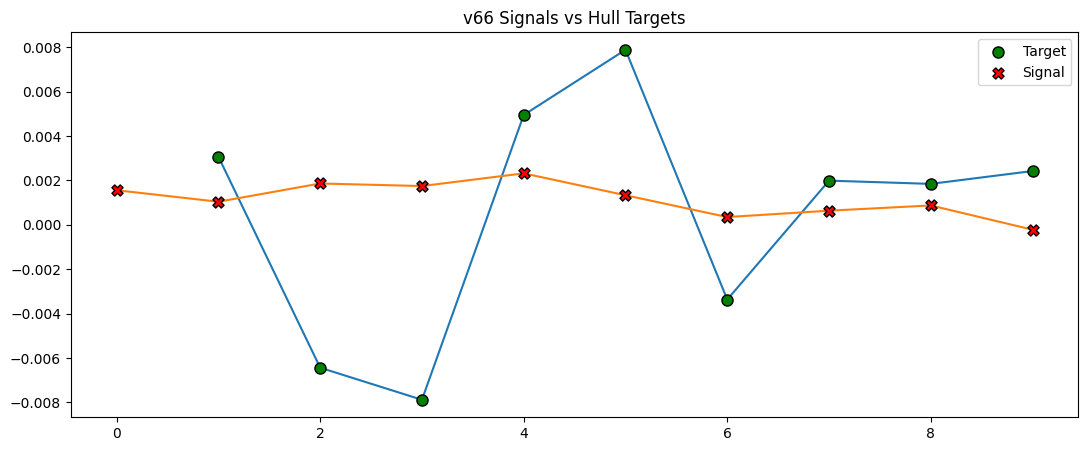

In [16]:
plt.figure(figsize=(13, 5))
plt.title(f'{model.name} Signals vs Hull Targets')
plt.plot(test_targets, zorder=-1)
indices = np.arange(test_targets.shape[0])
plt.scatter(indices, test_targets, label='Target', edgecolors='k', c='g', s=64)
predictions = model.predict(test_inputs)
plt.plot(predictions, zorder=-1)
plt.scatter(indices, predictions, label='Signal', marker='X', edgecolors='k', c='r', s=64)
plt.legend()
pass

In [17]:
MIN_INVESTMENT = 0
MAX_INVESTMENT = 2

def score(solution: pl.DataFrame, submission: pl.DataFrame) -> float:
    """
    Calculates a custom evaluation metric (volatility-adjusted Sharpe ratio).

    This metric penalizes strategies that take on significantly more volatility
    than the underlying market.

    Returns:
        float: The calculated adjusted Sharpe ratio.
    """

    if not submission['prediction'].dtype.is_numeric(): raise Exception('Predictions must be numeric')

    solution = solution.with_columns(position=submission['prediction'])

    pos_max = solution.select(pl.col('position').max()).item()
    if pos_max > MAX_INVESTMENT: raise Exception(f'Position of {pos_max} exceeds maximum of {MAX_INVESTMENT}')

    pos_min = solution.select(pl.col('position').min()).item()
    if pos_min < MIN_INVESTMENT: raise Exception(f'Position of {pos_min} below minimum of {MIN_INVESTMENT}')

    solution = solution.with_columns(strategy_returns=pl.col('risk_free_rate') * (1 - pl.col('position')) + pl.col('position') * pl.col('forward_returns'))

    n = len(solution)
    trading_days_per_yr = 252

    # Calculate strategy's Sharpe ratio
    strategy_excess_cumulative = solution.select((1 + (pl.col('strategy_returns') - pl.col('risk_free_rate'))).product()).item()
    strategy_mean_excess_return = (strategy_excess_cumulative) ** (1 / n) - 1
    strategy_std = solution.select(pl.col('strategy_returns').std()).item()
    if strategy_std == 0: raise Exception('Division by zero, strategy std is zero')
    sharpe = strategy_mean_excess_return / strategy_std * np.sqrt(trading_days_per_yr)
    strategy_volatility = float(strategy_std * np.sqrt(trading_days_per_yr) * 100)

    # Calculate market return and volatility
    market_excess_cumulative = solution.select((1 + (pl.col('forward_returns') - pl.col('risk_free_rate'))).product()).item()
    market_mean_excess_return = (market_excess_cumulative) ** (1 / n) - 1
    market_std = solution.select(pl.col('forward_returns').std()).item()
    market_volatility = float(market_std * np.sqrt(trading_days_per_yr) * 100)
    if market_volatility == 0: raise Exception('Division by zero, market std is zero')

    # Calculate the volatility penalty
    excess_vol = max(0, strategy_volatility / market_volatility - 1.2) if market_volatility > 0 else 0
    vol_penalty = 1 + excess_vol

    # Calculate the return penalty
    return_gap = max(0, (market_mean_excess_return - strategy_mean_excess_return) * 100 * trading_days_per_yr)
    return_penalty = 1 + (return_gap**2) / 100

    # Adjust the Sharpe ratio by the volatility and return penalty
    adjusted_sharpe = sharpe / (vol_penalty * return_penalty)
    return min(float(adjusted_sharpe), 1_000_000)

In [18]:
test_solution = test_data.with_columns(
    forward_returns=pl.col('lagged_forward_returns').shift(1),
    risk_free_rate=pl.col('lagged_risk_free_rate').shift(1),
    market_forward_excess_returns=pl.col('lagged_market_forward_excess_returns').shift(1),
).drop(['lagged_forward_returns','lagged_risk_free_rate','lagged_market_forward_excess_returns']).fill_null(0)
test_solution

D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,I8,…,P13,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0,0,0,1,0,0,1,0,1.577651,0.186177,0.001323,0.001323,0.001323,0.001323,0.955026,-0.583419,-0.704264,0.298365,-0.691361,1.259065,1.556516,1.71258,0.033069,0.333333,0.036376,-0.046483,-0.312326,0.913029,0.306217,1.025756,0.081349,0.478175,0.675627,0.699735,0.256283,0.36045,…,0.794643,-1.427834,0.352513,0.926257,0.431383,-0.476976,0.500245,1.784173,0.029762,0.294719,0.51455,0.446429,0.466551,0.085717,-0.230132,0.272487,-0.106894,0.199735,0.409392,0.532717,0.744048,0.440476,-0.654839,0.699735,0.699074,-0.5024,0.882937,0.892196,0.828042,0.999172,0.759921,-0.803127,0.170966,-0.751909,0.0,0.0,0.0
0,0,0,0,1,0,0,1,0,1.575182,0.185847,0.000992,0.000992,0.000992,0.000992,0.955357,-0.583074,-0.703759,0.297608,-0.504499,1.193468,1.554184,1.640054,0.032738,0.333003,0.036045,0.073582,-0.312345,0.91336,0.305886,0.989571,0.082672,0.477844,0.661527,0.719577,0.255952,0.361111,…,0.71131,-1.37652,0.953042,0.386905,0.523549,-0.421365,-0.234829,1.770175,0.03373,0.304496,0.638228,0.636905,1.849101,0.28169,-0.041995,0.448413,0.094321,0.215608,0.409392,0.597864,0.872354,0.691138,-0.583443,0.62996,0.598545,-0.394268,0.863757,0.699074,0.831349,1.120336,0.556217,-0.686192,0.141865,-0.660326,0.003541,0.000161,0.003068
0,0,0,0,1,0,0,0,1,1.57272,0.185516,0.000661,0.000661,0.000661,0.000661,0.955688,-0.083356,-0.573546,0.225822,-0.393903,1.123361,1.551723,1.562722,0.032407,0.332672,0.035714,0.033581,-0.312364,0.91369,0.291997,1.040514,0.081349,0.477513,0.655741,0.724206,0.22619,0.35582,…,0.212632,-1.34762,0.210979,0.635251,-1.138198,-0.494248,-1.042718,1.754171,0.032407,0.257609,0.082011,0.152116,-0.201611,0.346373,0.054032,0.137566,0.294305,0.194444,0.409392,0.596528,0.778439,0.634921,-0.483236,0.669974,0.603836,-0.17042,0.848545,0.647487,0.832672,1.088992,0.665344,-0.459367,0.199405,-0.510979,-0.005964,0.000162,-0.006437
0,0,0,0,1,0,0,0,1,1.570266,0.185185,0.019841,0.019841,0.006614,0.006614,0.956019,-0.083403,-0.57318,0.225094,-0.541646,1.167982,1.549272,1.611215,0.032077,0.332341,0.035384,0.033998,-0.312383,0.914021,0.267196,1.091376,0.085979,0.477183,0.648582,0.728175,0.230159,0.351852,…,0.660714,-1.399411,0.724868,0.21627,-0.230557,-0.318347,0.396917,1.769678,0.03373,0.20235,0.324074,0.212963,0.052878,-0.049023,0.120828,0.219577,0.137942,0.167328,0.409392,0.579726,0.449735,0.665344,-0.546298,0.590608,0.558862,-0.275099,0.826058,0.445767,0.835979,1.040988,0.594577,-0.561643,0.161706,-0.575997,-0.00741,0.00016,-0.007882
0,0,0,0,0,0,1,0,1,1.567818,0.184854,0.019511,0.019511,0.006283,0.006283,0.956349,-0.083449,-0.572813,0.224366,-0.714549,1.243713,1.542543,1.693604,0.031746,0.332011,0.035053,0.029586,-0.301855,0.914352,0.260913,1.011571,0.093915,0.476852,0.638667,0.729497,0.238757,0.353836,…,0.32672,-1.416282,0.611442,0.426257,0.046472,-0.262086,1.304142,1.785515,0.039683,0.230364,0.583995,0.445106,1.378927,-0.182025,0.01261,0.369048,0.011021,0.130291,0.409392,0.572656,0.489418,0.600529,-0.587258,0.46131,0.487434,-0.39548,0.80754,0.707672,0.839947,0.944593,0.715608,-0.692649,0.124669,-0.654045,0.00542,0.00016,0.004949
0,0,0,0,0,0,0,0,0,1.565379,0.184524,0.01918,0.01918,0.005952,0.005952,0.911376,-0.083496,-0.572447,0.223638,-0.122314,1.20925,1.540116,1.655174,0.031415,0.33168,0.034722,0.038269,-0.301876,0.914683,0.27414,0.984115,0.080688,0.476521,0.597442,0.718254,0.238757,0.351852,…,0.625331,-1.354498,0.046296,0.51455,0.276769,-0.261326,0.811754,1.784929,0.039683,0.249933,

In [21]:
signals = np.where(predictions > 0, 2.0, 0.0)
test_submission = pl.DataFrame(signals, schema=['prediction'])
test_submission

prediction
f64
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0


In [22]:
score(test_solution, test_submission)

0.7830626996240819